##**1. Persiapan Dataset**

Langkah pertama dimulai dengan mengimpor library yang diperlukan seperti pandas, numpy, matplotlib, dan sklearn. Dataset data_training.csv dimuat untuk proses pembangunan model, sedangkan data_testing.csv digunakan untuk prediksi akhir.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Muat data_training.csv ke dalam DataFrame
df_train = pd.read_csv('/content/data_training.csv')

# Tampilkan 5 baris pertama data pelatihan
print("Data Pelatihan (df_train):")
display(df_train.head())

Data Pelatihan (df_train):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [49]:
# Muat data_testing.csv ke dalam DataFrame
df_test = pd.read_csv('/content/data_testing.csv')

# Tampilkan 5 baris pertama data pengujian
print("\nData Pengujian (df_test):")
display(df_test.head())


Data Pengujian (df_test):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


Setelah memuat dataset, kita dapat melihat beberapa baris pertama dari data pelatihan (df_train) dan pengujian (df_test). Pemeriksaan awal ini membantu mengonfirmasi bahwa data telah dimuat dengan benar dan memberikan gambaran sekilas tentang struktur dan kolomnya.

## **2. Pengecekan Missing Value**

Dilakukan pemeriksaan untuk memastikan tidak ada data yang kosong pada dataset. Berdasarkan pengecekan menggunakan fungsi .isnull().sum(), tidak ditemukan nilai yang hilang pada setiap kolom fitur kimiawi. Hal ini menunjukkan bahwa data cukup bersih dan tidak memerlukan tahap imputasi (pengisian nilai kosong).

In [50]:
print("Nilai yang hilang di Data Pelatihan (df_train):")
display(df_train.isnull().sum())

print("\nNilai yang hilang di Data Pengujian (df_test):")
display(df_test.isnull().sum())

Nilai yang hilang di Data Pelatihan (df_train):


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Nilai yang hilang di Data Pengujian (df_test):


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Pengecekan ini secara eksplisit mengkonfirmasi tidak adanya nilai yang hilang di dataset pelatihan (df_train) dan pengujian (df_test). Output 0 untuk semua kolom berarti bahwa tidak ada imputasi data atau penanganan nilai yang hilang yang diperlukan, membuat dataset siap untuk pemrosesan lebih lanjut.

In [51]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Output df_train.info() memberikan ringkasan DataFrame, termasuk jumlah entri, jumlah kolom, tipe data untuk setiap kolom, dan jumlah nilai non-null. Langkah ini penting untuk memahami tipe data dan dengan cepat mengidentifikasi apakah ada kolom yang memiliki nilai yang hilang. Dalam kasus ini, semua kolom menunjukkan 857 entri non-null dari 857 total entri, menunjukkan tidak ada nilai yang hilang dalam set pelatihan.

## **3. Analisis Data Eksplorasi (EDA)**

Tahap ini bertujuan untuk memahami distribusi data dan hubungan antar variabel. Fokus utama adalah melihat bagaimana fitur seperti alcohol, volatile acidity, dan sulphates berkorelasi dengan variabel target quality. Visualisasi seperti heatmap korelasi dapat membantu menentukan fitur mana yang paling berpengaruh.

In [52]:
# Hitung matriks korelasi
correlation_matrix = df_train.corr()

# Tampilkan matriks korelasi dengan 'quality'
print("Matriks korelasi dengan 'quality':")
display(correlation_matrix['quality'].sort_values(ascending=False))

Matriks korelasi dengan 'quality':


,quality
quality,1.000000
alcohol,0.473555
sulphates,0.260703
citric acid,0.221263
fixed acidity,0.092714
Id,0.049030
residual sugar,-0.020511
pH,-0.033199
free sulfur dioxide,-0.054509
chlorides,-0.144946


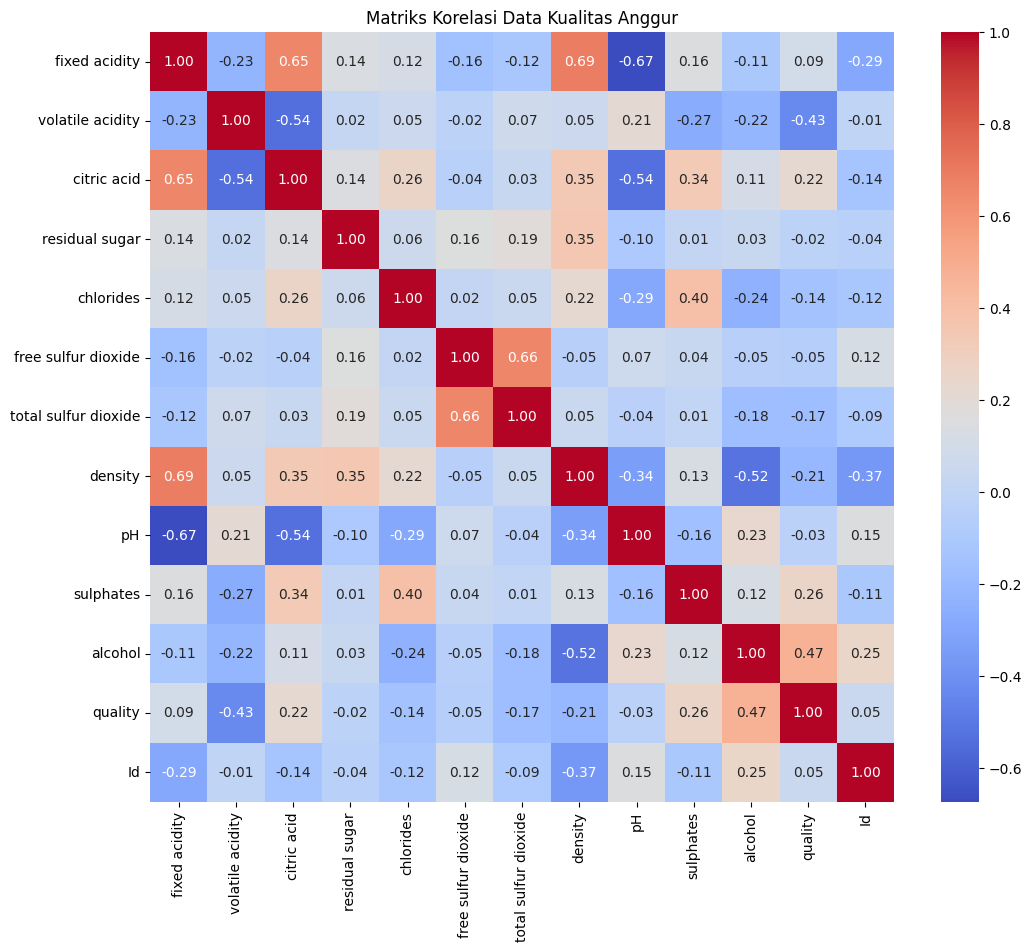

In [53]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Data Kualitas Anggur')
plt.show()

In [54]:
# Korelasi fitur-fitur spesifik dengan 'quality'
print("Korelasi 'alcohol' dengan 'quality':", correlation_matrix.loc['alcohol', 'quality'])
print("Korelasi 'volatile acidity' dengan 'quality':", correlation_matrix.loc['volatile acidity', 'quality'])
print("Korelasi 'sulphates' dengan 'quality':", correlation_matrix.loc['sulphates', 'quality'])

Korelasi 'alcohol' dengan 'quality': 0.473554609708634
Korelasi 'volatile acidity' dengan 'quality': -0.43005867190527175
Korelasi 'sulphates' dengan 'quality': 0.2607027330719354


Bagian Analisis Data Eksplorasi (EDA) pertama-tama menghitung matriks korelasi untuk semua fitur dan secara spesifik menampilkan korelasi setiap fitur dengan variabel target quality. Heatmap secara visual merepresentasikan korelasi ini, menunjukkan kekuatan dan arah hubungan. Nilai positif (warna lebih hangat) menunjukkan korelasi positif (misalnya, kadar alkohol yang lebih tinggi sering berkorelasi dengan kualitas yang lebih tinggi), sementara nilai negatif (warna lebih dingin) menunjukkan korelasi negatif (misalnya, keasaman volatil yang lebih tinggi sering berkorelasi dengan kualitas yang lebih rendah). Nilai korelasi individu untuk alcohol, volatile acidity, dan sulphates dengan quality kemudian dicetak, mengkonfirmasi pengaruh masing-masing terhadap kualitas anggur.

/tmp/ipykernel_2262/94861766.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_train['quality'], bins=range(3, 10), kde=False, stat='count', palette='viridis')


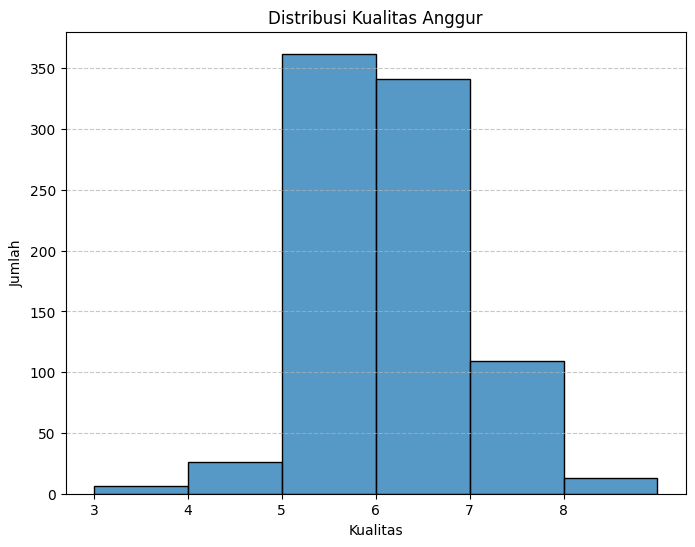

In [55]:
# Pastikan df_train dimuat untuk sel ini
df_train = pd.read_csv('/content/data_training.csv')

plt.figure(figsize=(8, 6))
sns.histplot(df_train['quality'], bins=range(3, 10), kde=False, stat='count', palette='viridis')
plt.title('Distribusi Kualitas Anggur')
plt.xlabel('Kualitas')
plt.ylabel('Jumlah')
plt.xticks(range(3, 9)) # Pastikan semua level kualitas ditampilkan
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Histogram di atas menunjukkan distribusi nilai quality dalam dataset pelatihan. Beberapa poin penting yang dapat diamati adalah:

*   **Rentang Kualitas**: Kualitas anggur dalam dataset ini berkisar dari 3 hingga 8.
*   **Kelas Mayoritas**: Kualitas 5 dan 6 adalah kategori yang paling sering muncul, menunjukkan bahwa sebagian besar anggur dalam dataset ini memiliki kualitas sedang.
*   **Kelas Minoritas**: Kualitas 3, 4, 7, dan 8 memiliki jumlah sampel yang jauh lebih sedikit, dengan kualitas 3 dan 8 sangat jarang. Ini mengindikasikan adanya ketidakseimbangan kelas (class imbalance) di mana model mungkin cenderung kurang terlatih untuk memprediksi kualitas yang ekstrem.

Distribusi ini penting untuk dipahami karena dapat memengaruhi bagaimana model klasifikasi belajar dan seberapa baik kinerjanya pada setiap kelas kualitas.

## **4. Pemisahan Fitur dan Target**

Fitur-fitur kimiawi dipisahkan dari target prediksi. Variabel dependen adalah kolom quality, sedangkan variabel independen adalah seluruh kolom fitur kimiawi. Kolom Id dihapus dari data latih karena merupakan identitas unik yang tidak memiliki pengaruh ilmiah terhadap kualitas anggur.

In [56]:
# Pisahkan fitur (X) dan target (y) untuk data pelatihan
X_train = df_train.drop(columns=['quality', 'Id'])
y_train = df_train['quality']

# Siapkan fitur untuk data testing (hapus 'Id' jika ada, 'quality' tidak ada di data testing)
X_test = df_test.drop(columns=['Id'])

print("Bentuk X_train:", X_train.shape)
print("Bentuk y_train:", y_train.shape)
print("Bentuk X_test:", X_test.shape)

display(X_train.head())
display(y_train.head())
display(X_test.head())

Bentuk X_train: (857, 11)
Bentuk y_train: (857,)
Bentuk X_test: (286, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0


,quality
0,5
1,5
2,7
3,6
4,6


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000


Pada langkah ini, dataset dibagi menjadi fitur (X) dan variabel target (y). Untuk data pelatihan, quality ditetapkan sebagai variabel target, dan Id dihapus dari fitur karena merupakan pengidentifikasi dan bukan fitur prediktif. Demikian pula, Id dihapus dari fitur pengujian (X_test). Bentuk DataFrame yang dihasilkan (X_train, y_train, X_test) dicetak untuk mengkonfirmasi dimensi, dan .head() masing-masing ditampilkan untuk verifikasi cepat pemisahan.

## **5. Pembagian Data (Train-Test Split)**

Dataset data_training.csv dibagi menjadi dua bagian:

*   **Data Train (80%)**: Digunakan untuk melatih algoritma agar dapat mengenali pola data.

*   **Data Validation (20%)**: Digunakan untuk menguji performa model secara internal sebelum diterapkan pada data testing yang sebenarnya. Proses ini penting untuk mendeteksi adanya _overfitting_.

In [57]:
# Bagi data pelatihan menjadi set pelatihan dan validasi (80% latih, 20% validasi)
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print("Bentuk X_train_split:", X_train_split.shape)
print("Bentuk y_train_split:", y_train_split.shape)
print("Bentuk X_val:", X_val.shape)
print("Bentuk y_val:", y_val.shape)

Bentuk X_train_split: (685, 11)
Bentuk y_train_split: (685,)
Bentuk X_val: (172, 11)
Bentuk y_val: (172,)


In [58]:
print("X_train_split head:")
display(X_train_split.head())

print("y_train_split head:")
display(y_train_split.head())

print("X_val head:")
display(X_val.head())

print("y_val head:")
display(y_val.head())

X_train_split head:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
177,9.0,0.785,0.24,1.70,0.078,10.0,21.0,0.99692,3.29,0.67,10.0
505,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9
17,7.7,0.490,0.26,1.90,0.062,9.0,31.0,0.99660,3.39,0.64,9.6
738,8.0,0.380,0.44,1.90,0.098,6.0,15.0,0.99560,3.30,0.64,11.4
236,7.4,0.580,0.00,2.00,0.064,7.0,11.0,0.99562,3.45,0.58,11.3


y_train_split head:


,quality
177,5
505,5
17,5
738,6
236,6


X_val head:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
492,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.100000
65,7.7,0.490,0.26,1.9,0.062,9.0,31.0,0.99660,3.39,0.64,9.600000
110,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.400000
569,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.500000
625,5.3,0.470,0.11,2.2,0.048,16.0,89.0,0.99182,3.54,0.88,13.566667


y_val head:


,quality
492,5
65,5
110,5
569,5
625,7


Pada langkah pembagian data (Train-Test Split), dataset pelatihan awal (X_train, y_train) dibagi menjadi dua subset:

*   **Data Pelatihan (Training Data)**: Ini adalah bagian terbesar dari data, yaitu 80%, yang digunakan untuk melatih model. Hasilnya adalah X_train_split dan y_train_split dengan bentuk (685, 11) dan (685,) secara berturut-turut. Ini berarti ada 685 sampel pelatihan dengan 11 fitur dan 685 nilai target.

*   **Data Validasi (Validation Data)**: Ini adalah 20% sisa dari data pelatihan, digunakan untuk mengevaluasi kinerja model selama pengembangan dan menyetel _hyperparameter_. Ini membantu mendeteksi _overfitting_ sebelum menguji model pada data pengujian akhir yang belum pernah dilihat. Hasilnya adalah X_val dan y_val dengan bentuk (172, 11) dan (172,).

Parameter **random_state=42** digunakan untuk memastikan bahwa pembagian data selalu sama setiap kali kode dijalankan, sehingga hasilnya dapat direproduksi. **stratify=y_train** sangat penting dalam kasus ini karena memastikan distribusi kelas quality yang tidak seimbang dalam y_train dipertahankan secara proporsional di kedua set y_train_split dan y_val.

## **6. Feature Scaling**

Karena fitur kimiawi memiliki rentang nilai yang sangat berbeda (misalnya density yang mendekati angka 1, sementara total sulfur dioxide mencapai angka puluhan atau ratusan), maka dilakukan **Standardization** menggunakan StandardScaler. Langkah ini memastikan semua fitur berada pada skala yang sama sehingga model dapat belajar dengan lebih stabil dan cepat.

In [59]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Sesuaikan scaler pada data pelatihan (X_train_split) dan transformasikan
X_train_scaled = scaler.fit_transform(X_train_split)

# Transformasikan data validasi dan pengujian menggunakan scaler yang *sama*
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Konversi array yang diskalakan kembali ke DataFrame untuk inspeksi yang lebih mudah dan mempertahankan nama kolom
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_split.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("5 baris pertama X_train_scaled:")
display(X_train_scaled.head())
print("5 baris pertama X_val_scaled:")
display(X_val_scaled.head())
print("5 baris pertama X_test_scaled:")
display(X_test_scaled.head())

5 baris pertama X_train_scaled:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.434650,1.433978,-0.146214,-0.640901,-0.172558,-0.571978,-0.787661,0.142301,-0.157984,0.117584,-0.398729
1,-0.620733,1.101689,-1.132212,1.767245,0.010029,-1.145491,-1.095174,-0.237517,0.648118,-1.659612,0.444166
2,-0.327571,-0.199778,-0.042425,-0.477637,-0.537733,-0.667563,-0.480147,-0.026507,0.513768,-0.072830,-0.773348
3,-0.151674,-0.808975,0.891679,-0.477637,0.283910,-0.954320,-0.972169,-0.554032,-0.090809,-0.072830,0.912441
4,-0.503468,0.298656,-1.391685,-0.396005,-0.492086,-0.858734,-1.095174,-0.543481,0.916819,-0.453658,0.818786


5 baris pertama X_val_scaled:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.620733,0.935544,-0.717055,-0.396005,-0.218205,-0.380807,-0.818412,-0.627885,-0.157984,-0.707543,-0.305074
1,-0.327571,-0.199778,-0.042425,-0.477637,-0.537733,-0.667563,-0.480147,-0.026507,0.513768,-0.072830,-0.773348
2,-0.503468,0.741708,-1.391685,-0.559269,-0.241029,-0.285221,-0.203385,0.606522,1.319870,-0.580600,-0.960658
3,-1.324321,-0.144396,-1.391685,-0.885797,-0.651850,-0.094051,-0.633904,-1.144859,0.312242,-1.278784,-0.867003
4,-1.734747,-0.310541,-0.820844,-0.232741,-0.857261,0.001535,1.303431,-2.548074,1.521396,1.450481,2.941631


5 baris pertama X_test_scaled:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.855262,0.464801,-1.184107,-0.804165,-0.651850,-1.049905,-1.125926,-0.738665,0.715294,-0.326715,-0.867003
1,-0.796630,1.738576,-0.301898,1.318268,-0.263852,0.001535,0.565398,0.933587,1.454221,0.434940,-1.116750
2,-0.737997,0.298656,-0.768950,-0.477637,0.124146,1.722074,2.379728,-0.554032,0.849644,-1.088370,0.069546
3,-0.268938,-0.255159,2.137150,-0.640901,7.518933,-0.189636,-0.449396,-0.047608,-1.501489,2.592964,-1.241623
4,2.486782,0.409419,1.151152,1.481532,0.329557,-1.049905,-1.002920,2.294600,-0.426685,0.561883,1.380716


Penskalaan fitur dilakukan menggunakan StandardScaler. Proses ini mengubah fitur sehingga memiliki mean 0 dan standar deviasi 1. Hal ini penting karena fitur-fitur seperti density dan total sulfur dioxide memiliki rentang yang sangat berbeda, dan banyak algoritma _machine learning_ berkinerja lebih baik ketika fitur berada pada skala yang serupa. Scaler di-_fit_ pada data pelatihan (X_train_split) dan kemudian digunakan untuk _transform_ data pelatihan, validasi, dan pengujian. Data yang diskala diubah kembali menjadi DataFrame, dan 5 baris pertama ditampilkan untuk menunjukkan efek penskalaan.

## **7. Model Random Forest**

**Random Forest** adalah algoritma pembelajaran _ensemble_ yang sangat populer dan serbaguna, digunakan untuk tugas klasifikasi maupun regresi. Algoritma ini bekerja dengan membangun banyak pohon keputusan (_decision trees_) secara independen dan kemudian menggabungkan hasil prediksi dari masing-masing pohon untuk mendapatkan prediksi akhir.

**Mengapa Random Forest Digunakan di Sini?**

1.  **Mengurangi Overfitting**: Dengan melatih banyak pohon pada subset data dan fitur yang berbeda, Random Forest secara efektif mengurangi risiko _overfitting_ yang sering terjadi pada satu pohon keputusan tunggal.
2.  **Stabilitas dan Akurasi**: Kombinasi prediksi dari banyak pohon biasanya menghasilkan model yang lebih stabil dan lebih akurat dibandingkan model yang hanya menggunakan satu pohon.
3.  **Penanganan Ketidakseimbangan Kelas**: Parameter class_weight=balanced` secara otomatis menyesuaikan bobot kelas dalam model, memberikan bobot lebih tinggi pada kelas minoritas agar tidak terabaikan selama pelatihan, yang sangat penting mengingat distribusi kualitas anggur yang tidak seimbang.

In [60]:
# Inisialisasi Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=500,  # Ditingkatkan dari 300
    max_depth=15,    # Tetapkan max_depth terbatas untuk mencegah overfitting
    min_samples_split=2,
    min_samples_leaf=2,  # Ditambahkan min_samples_leaf untuk mencegah overfitting
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Latih model menggunakan data pelatihan yang diskalakan
rf_model.fit(X_train_scaled, y_train_split)

print("Model Random Forest Classifier berhasil dilatih!")

Model Random Forest Classifier berhasil dilatih!



**Konfigurasi Hyperparameter yang Digunakan:**

*   n_estimators = 500 : Jumlah pohon keputusan yang dibangun dalam hutan. Semakin banyak pohon, model cenderung lebih stabil dan akurat, meskipun dengan biaya komputasi yang lebih tinggi. Nilai 500 dipilih untuk memastikan model memiliki cukup suara untuk membuat prediksi yang robust.
*   max_depth = 15: Kedalaman maksimum setiap pohon keputusan. Pembatasan ini mencegah pohon tumbuh terlalu dalam dan _menghafal_ data pelatihan, yang merupakan salah satu penyebab _overfitting_.
*   min_samples_leaf = 2 : Jumlah minimum sampel yang harus ada di setiap daun (node terminal) pohon. Parameter ini juga berfungsi untuk mencegah _overfitting_ dengan memastikan bahwa setiap keputusan didasarkan pada sejumlah sampel yang memadai.
*   random_state = 42 : Digunakan untuk memastikan reproduktibilitas hasil. Setiap kali kode dijalankan dengan random_state yang sama, pembagian data dan inisialisasi model akan konsisten.
*   n_jobs = -1: Menginstruksikan model untuk menggunakan semua _core_ CPU yang tersedia, mempercepat proses pelatihan.

## **8. Evaluasi Model**

Model yang telah dilatih kemudian diuji menggunakan data validasi. Metrik evaluasi yang digunakan mencakup:

*   Accuracy Score: Untuk melihat persentase prediksi yang benar secara keseluruhan
*   Confusion Matrix: Untuk melihat detail prediksi yang benar dan salah pada setiap kategori kualitas.

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Prediksi pada set validasi menggunakan classifier
y_pred_val_class = rf_model.predict(X_val_scaled)

# Hitung Confusion Matrix
conf_matrix_val_class = confusion_matrix(y_val, y_pred_val_class)

print(f"\nEvaluasi Model Random Forest Classifier pada Set Validasi:")
print(f"\n Confusion Matrix:\n{conf_matrix_val_class}")


Evaluasi Model Random Forest Classifier pada Set Validasi:

 Confusion Matrix:
[[ 0  0  0  1  0  0]
 [ 1  0  4  0  0  0]
 [ 1  1 55 15  1  0]
 [ 0  0 20 42  6  0]
 [ 0  0  0 15  7  0]
 [ 0  0  0  0  2  1]]


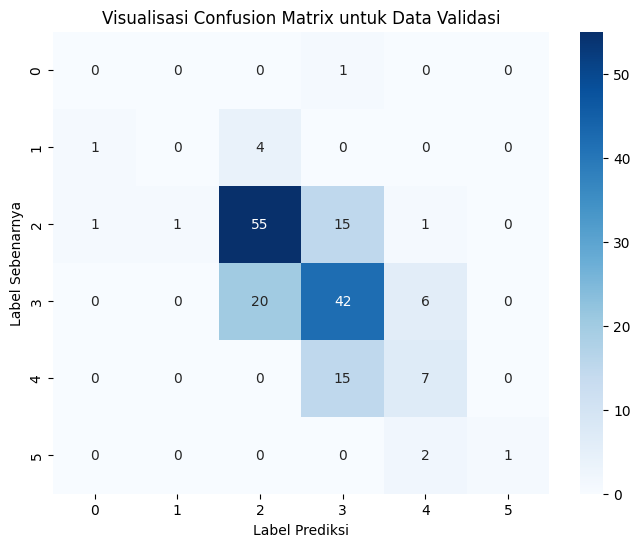

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_val_class, annot=True, fmt='d', cmap='Blues')
plt.title('Visualisasi Confusion Matrix untuk Data Validasi')
plt.xlabel('Label Prediksi')
plt.ylabel('Label Sebenarnya')
plt.show()

Confusion Matrix adalah tabel yang menunjukkan kinerja model klasifikasi, dengan baris merepresentasikan kelas aktual dan kolom merepresentasikan kelas prediksi. Angka pada diagonal utama menunjukkan prediksi yang benar, sedangkan angka di luar diagonal menunjukkan kesalahan prediksi.

*   **Prediksi Benar (Diagonal)**: Model paling baik memprediksi kualitas 5 (55) dan 6 (42). Untuk kualitas 3, 4, dan 8, prediksi benar sangat sedikit atau nol.
*   **Prediksi Salah (Non-Diagonal)**: Model sering salah memprediksi kelas minoritas dan cenderung mengklasifikasikannya ke kelas yang berdekatan atau lebih sering muncul. Contoh: kualitas 5 sering salah diprediksi sebagai kualitas 6 (15 kasus), dan kualitas 6 sering salah diprediksi sebagai kualitas 5 (20 kasus). Kualitas 7 sering salah diprediksi sebagai kualitas 6 (15 kasus).

**Kesimpulan**: Model Random Forest cukup baik untuk kelas mayoritas (5 dan 6), tetapi kesulitan dengan kelas minoritas (3, 4, 7, 8) karena ketidakseimbangan kelas, meskipun class_weight=balanced telah digunakan.

In [63]:
from sklearn.metrics import classification_report

print("\nClassification Report untuk Data Validasi:")
print(classification_report(y_val, y_pred_val_class))


Classification Report untuk Data Validasi:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.75      0.72        73
           6       0.58      0.62      0.60        68
           7       0.44      0.32      0.37        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.45      0.34      0.36       172
weighted avg       0.60      0.61      0.60       172



Classification Report menampilkan metrik evaluasi per kelas (quality 3 hingga 8):

* **Precision**: Seberapa akurat model saat memprediksi kelas positif. Misalnya, untuk kelas 5, 70% dari prediksi kualitas 5 benar.
* **Recall**: Seberapa baik model menemukan semua instance positif dari sebuah kelas. Untuk kelas 5, model berhasil mengidentifikasi 75% dari semua anggur yang benar-benar berkualitas 5.
* **F1-Score**: Gabungan dari precision dan recall, berguna untuk data yang tidak seimbang.
* **Support**: Jumlah sampel sebenarnya di setiap kelas.

**Ringkasan Hasil :**

* **Kelas 5 dan 6 (Mayoritas)**: Model
performa cukup baik dengan precision dan recall yang relatif tinggi (sekitar 0.70-0.75).
* **Kelas 3 dan 4 (Minoritas)**: Model gagal total (precision, recall, f1-score 0.00) karena jumlah sampel yang sangat sedikit.
* **Kelas 7 dan 8 (Minoritas)**: Performa kurang baik. Untuk kelas 8, presisi tinggi (1.00) tapi recall sangat rendah (0.33), artinya model jarang memprediksi kelas 8 tapi jika memprediksi, prediksinya benar.

**Akurasi Keseluruhan**: 0.61. Ini adalah persentase prediksi yang benar secara keseluruhan.

**Kesimpulan Singkat**: Model ini cukup baik untuk memprediksi kualitas anggur di kelas mayoritas (5 dan 6), tetapi sangat kesulitan untuk kelas minoritas (terutama 3 dan 4) karena masalah ketidakseimbangan data, meskipun sudah menggunakan class_weight=balanced.

## **9. Prediksi Data Testing**

Model final digunakan untuk memprediksi nilai quality pada file data_testing.csv. Sebelum diprediksi, data testing juga diproses dengan scaler yang sama agar format fiturnya konsisten dengan data saat pelatihan.

In [64]:
# Prediksi pada data pengujian menggunakan classifier
y_pred_test_class = rf_model.predict(X_test_scaled)

# Tambahkan prediksi ke df_test dalam kolom baru untuk perbandingan
df_test['quality_prediction'] = y_pred_test_class

df_test = df_test.drop(columns=['quality_improved_prediction'], errors='ignore')

print("Prediksi untuk data pengujian menggunakan model telah dibuat dan ditambahkan ke df_test.")
display(df_test.head())

Prediksi untuk data pengujian menggunakan model telah dibuat dan ditambahkan ke df_test.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id,quality_prediction
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222,5
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514,6
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417,5
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754,5
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516,6


In [65]:
# Hitung kemunculan setiap nilai 'quality' yang diprediksi dari model
quality_counts = df_test['quality_prediction'].value_counts().sort_index()
print("Jumlah prediksi kualitas dari model di data testing:")
display(quality_counts)

Jumlah prediksi kualitas dari model di data testing:


,count
quality_prediction,
3,1
4,2
5,131
6,127
7,24
8,1


Setelah model RandomForestClassifier dilatih dan dievaluasi, langkah selanjutnya adalah menggunakan model final tersebut untuk membuat prediksi pada X_test_scaled, yaitu data pengujian yang telah diskalakan dan belum pernah dilihat oleh model.

*   **y_pred_test_class = rf_model.predict(X_test_scaled)**: Baris kode ini menjalankan proses prediksi. Model rf_model mengambil fitur-fitur dari X_test_scaled sebagai input dan mengeluarkan serangkaian nilai quality yang diprediksi untuk setiap sampel di data pengujian.

*   **df_test[quality_prediction] = y_pred_test_class**: Hasil prediksi (y_pred_test_class) kemudian ditambahkan sebagai kolom baru bernama quality_prediction ke DataFrame df_test asli. Ini memudahkan kita untuk melihat hasil prediksi berdampingan dengan fitur asli dari data pengujian.

*   **quality_counts = df_test[quality_prediction].value_counts().sort_index()**: Kode ini menghitung berapa kali setiap nilai kualitas (dari 3 hingga 8) muncul dalam hasil prediksi. Ini memberikan gambaran tentang distribusi kualitas anggur yang diprediksi oleh model untuk data pengujian.

Setelah membuat prediksi pada data pengujian, terlihat bahwa model cenderung memprediksi kualitas 5 dan 6 sebagai kelas yang paling dominan. Ini konsisten dengan observasi dari tahap analisis data eksplorasi dan evaluasi model, di mana kelas 5 dan 6 merupakan kelas mayoritas. Jumlah prediksi untuk kelas minoritas seperti 3, 4, dan 8 sangat sedikit, menunjukkan bahwa bias model terhadap kelas mayoritas masih bertahan dalam hasil akhir prediksi, meskipun upaya penyeimbangan kelas telah dilakukan.

## **10. Ekspor Hasil Prediksi**

Hasil prediksi akhir akan digabungkan kembali dengan kolom Id asli dari data testing. File kemudian akan disimpan dalam format CSV dengan nama hasilprediksi_006.csv yang hanya berisi dua kolom: Id dan quality

In [66]:
# Buat DataFrame dengan 'Id' dari df_test dan 'quality' yang diprediksi
submission_df = pd.DataFrame({'Id': df_test['Id'], 'quality': y_pred_test_class})

# Simpan DataFrame ke file CSV
submission_df.to_csv('hasilprediksi_006.csv', index=False)

print("Hasil prediksi disimpan ke 'hasilprediksi_006.csv'")
display(submission_df.head())

Hasil prediksi disimpan ke 'hasilprediksi_006.csv'


,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6


Langkah terakhir melibatkan pembuatan DataFrame submission, submission_df, yang menyertakan Id asli dari df_test dan prediksi y_pred_test_class. DataFrame ini kemudian disimpan ke file CSV bernama hasilprediksi_006.csv tanpa menyertakan indeks DataFrame.

## **Kesimpulan**

Model RandomForestClassifier dilatih untuk memprediksi kualitas anggur. Evaluasi model pada data validasi menunjukkan **akurasi keseluruhan 0.61**. Namun, analisis melalui Confusion Matrix dan Classification Report menunjukkan bahwa model berkinerja baik untuk kelas mayoritas (kualitas 5 dan 6), dengan precision dan recall yang relatif tinggi.

Sebaliknya, model **sangat kesulitan dalam memprediksi kelas minoritas (kualitas 3, 4, 7, dan 8)**. Khususnya untuk kualitas 3 dan 4, model gagal total dalam memprediksi, ditunjukkan dengan precision, recall, dan f1-score sebesar 0.00 akibat jumlah sampel yang sangat sedikit (ketidakseimbangan kelas). Meskipun class_weight=balanced sudah digunakan, efek ketidakseimbangan kelas ini masih signifikan.

Pada data testing, model cenderung memprediksi kualitas yang dominan (5 dan 6), mengindikasikan bahwa bias kelas minoritas masih terbawa dalam hasil prediksi. Secara keseluruhan, model efektif untuk kelas mayoritas, tetapi penanganan ketidakseimbangan kelas tetap krusial untuk meningkatkan kemampuan prediksi pada kualitas anggur yang lebih ekstrem.